In [1]:
import tensorflow as tf
import numpy as np
import tensorflow.keras as keras


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
import matplotlib.pyplot as plt

In [4]:
path=tf.keras.utils.get_file('shakespeare.txt','https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text=open(path,'r',encoding='utf-8').read().lower()

In [5]:
print(text[:5000])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for the gods know i
speak this in hunger for bread, not in thirst for revenge.



In [6]:
print("total characters:",len(text))
print("total words:",len(text.split()))

total characters: 1115394
total words: 202651


In [7]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])
word_index=tokenizer.word_index  #dictionary of characters and their corresponding integer values
vocab_size=len(word_index)+1  
print("unique characters:",len(word_index))
print("vocabulary size:",vocab_size)

unique characters: 12632
vocabulary size: 12633


In [8]:
for word,index in list(word_index.items())[:10]:
    print(word,index)
    

the 1
and 2
to 3
i 4
of 5
you 6
my 7
a 8
that 9
in 10


In [9]:
sequences=tokenizer.texts_to_sequences([text])[0]
print(sequences[:10])

[88, 269, 139, 35, 969, 143, 668, 127, 15, 102]


In [10]:
lines=text.split('\n')
input_sequences=[]
for line in lines:
    token_list=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequences.append(n_gram_sequence)
print("length of input sequences:",len(input_sequences))

length of input sequences: 171312


In [11]:
## part -2 
max_sequence_len=max([len(x) for x in input_sequences])
print("max sequence length:",max_sequence_len)

max sequence length: 16


In [12]:
#apply padding
input_sequences=np.array(pad_sequences(input_sequences,maxlen=max_sequence_len))
print(input_sequences[:10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0  88 269]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 139  35]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 139  35 969]
 [  0   0   0   0   0   0   0   0   0   0   0   0 139  35 969 143]
 [  0   0   0   0   0   0   0   0   0   0   0 139  35 969 143 668]
 [  0   0   0   0   0   0   0   0   0   0 139  35 969 143 668 127]
 [  0   0   0   0   0   0   0   0   0 139  35 969 143 668 127  15]
 [  0   0   0   0   0   0   0   0 139  35 969 143 668 127  15 102]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 102 102]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  88 269]]


In [13]:
 # Split into x & y

x = input_sequences[:, :- 1]
y = input_sequences[:,-1]

print("x shape:",x.shape)
print("y shape:",y.shape)

# Convert o/p into categgorical

y = tf.keras.utils.to_categorical(y,num_classes = vocab_size)   

x shape: (171312, 15)
y shape: (171312,)


In [14]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

In [15]:
model = Sequential()
model.add(Input(shape=(max_sequence_len-1,)))
model.add(Embedding(input_dim=vocab_size, output_dim=100))
model.add(LSTM(100))
model.add(Dense(vocab_size,activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,275,933 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,633 (9.99 MB)

 Trainable params: 2,619,633 (9.99 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
history=model.fit(x,y,epochs=10,batch_size=128,validation_split=0.2)

Epoch 1/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.0373 - loss: 6.9138 - val_accuracy: 0.0373 - val_loss: 6.8253
Epoch 2/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.0584 - loss: 6.4354 - val_accuracy: 0.0632 - val_loss: 6.6529
Epoch 3/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - accuracy: 0.0831 - loss: 6.1432 - val_accuracy: 0.0801 - val_loss: 6.5813
Epoch 4/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.0948 - loss: 5.9377 - val_accuracy: 0.0819 - val_loss: 6.5733
Epoch 5/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.1025 - loss: 5.7658 - val_accuracy: 0.0837 - val_loss: 6.5802
Epoch 6/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.1097 - loss: 5.6100 - val_accuracy: 0.0863 - val_loss: 6.6030
Epoch 7/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.1172 - loss: 5.4637 - val_accuracy: 0.0896 - val_loss: 6.6470
Epoch 8/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.1233 -

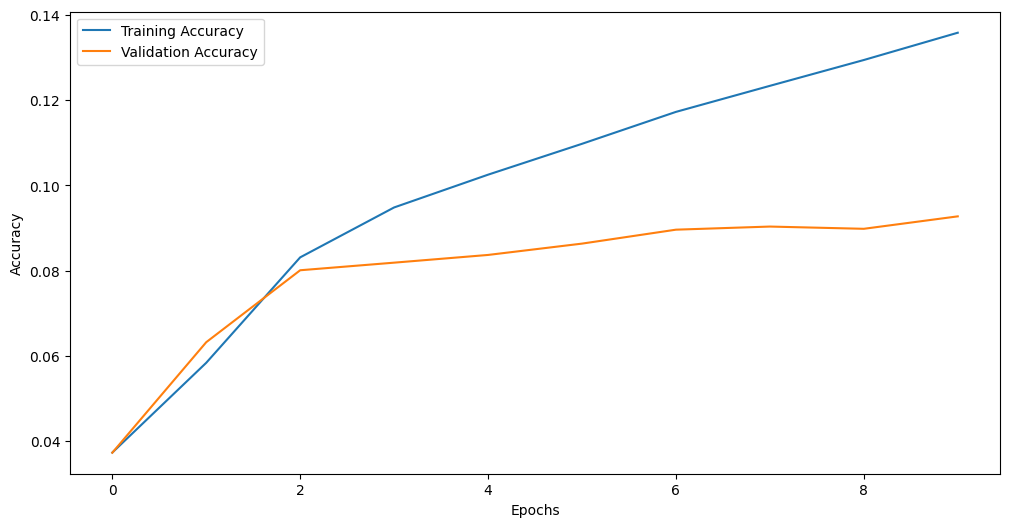

In [20]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend([
    'Training Accuracy',
    'Validation Accuracy',
])
plt.show()

In [21]:
def predict_next_word(seed_text):
    # Convert text into sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    if len(token_list) == 0:
        return ""
    # Apply padding
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
    # Predict probabilities
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=-1)[0]
    # Map index back to word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            output_word = word
            break
    return seed_text + " " + output_word


In [30]:
seed="i want to be"
print(predict_next_word(seed))

i want to be a
